#  Modèle Baseline 1 — One-Hot (CountVectorizer) + Réseau Neuronal PyTorch

**Architecture** : CountVectorizer → Linear(512) → ReLU → Dropout → Linear(128) → ReLU → Dropout → Linear(3)


In [2]:
# ═══════════════════════════════════════════════════════
# SETUP
# ═══════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/Projet_Sentiment_Analysis'
DATA_DIR    = os.path.join(PROJECT_DIR, 'data')
FIG_DIR     = os.path.join(PROJECT_DIR, 'figures')

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

LABEL_NAMES = {0: 'négatif', 1: 'neutre', 2: 'positif'}
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device : {DEVICE}")

Mounted at /content/drive
✅ Device : cpu


In [3]:
# ═══════════════════════════════════════════════════════
# CHARGEMENT DES DONNÉES
# ═══════════════════════════════════════════════════════
df_train = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
df_val   = pd.read_csv(os.path.join(DATA_DIR, 'val.csv'))
df_test  = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

X_train_text = df_train['texte_clean'].fillna('').values
X_val_text   = df_val['texte_clean'].fillna('').values
X_test_text  = df_test['texte_clean'].fillna('').values

y_train = df_train['label'].values
y_val   = df_val['label'].values
y_test  = df_test['label'].values

print(f" Train: {len(X_train_text)} | Val: {len(X_val_text)} | Test: {len(X_test_text)}")

📊 Train: 9285 | Val: 1161 | Test: 1161


In [4]:
# ═══════════════════════════════════════════════════════
# VECTORISATION ONE-HOT (CountVectorizer)
# ═══════════════════════════════════════════════════════
vectorizer = CountVectorizer(max_features=10000, min_df=2, binary=True)

X_train = vectorizer.fit_transform(X_train_text).toarray()
X_val   = vectorizer.transform(X_val_text).toarray()
X_test  = vectorizer.transform(X_test_text).toarray()

VOCAB_SIZE = X_train.shape[1]
print(f" Taille du vocabulaire : {VOCAB_SIZE}")

# Convertir en tenseurs PyTorch
X_train_t = torch.FloatTensor(X_train).to(DEVICE)
y_train_t = torch.LongTensor(y_train).to(DEVICE)
X_val_t   = torch.FloatTensor(X_val).to(DEVICE)
y_val_t   = torch.LongTensor(y_val).to(DEVICE)
X_test_t  = torch.FloatTensor(X_test).to(DEVICE)
y_test_t  = torch.LongTensor(y_test).to(DEVICE)

# DataLoaders
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True)

📊 Taille du vocabulaire : 4117


In [5]:
# ═══════════════════════════════════════════════════════
# MODÈLE : RÉSEAU NEURONAL 2 COUCHES
# ═══════════════════════════════════════════════════════
class SentimentNN(nn.Module):
    def __init__(self, input_dim, num_classes=3):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.model(x)

model = SentimentNN(VOCAB_SIZE).to(DEVICE)
print(f" Paramètres : {sum(p.numel() for p in model.parameters()):,}")

# Class weights pour gérer le déséquilibre
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight('balanced', classes=np.array([0,1,2]), y=y_train)
class_weights = torch.FloatTensor(cw).to(DEVICE)
print(f" Class weights : {cw.round(4)}")

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

📐 Paramètres : 2,174,467
⚖️ Class weights : [0.9801 4.6263 0.5671]


In [6]:
# ═══════════════════════════════════════════════════════
# ENTRAÎNEMENT
# ═══════════════════════════════════════════════════════
EPOCHS = 20
PATIENCE = 3

history = {'train_loss': [], 'val_loss': [], 'val_f1': []}
best_f1 = 0
patience_counter = 0

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)

    # --- Validation ---
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_t)
        val_loss = criterion(val_outputs, y_val_t).item()
        val_preds = val_outputs.argmax(dim=1).cpu().numpy()
        val_f1 = f1_score(y_val, val_preds, average='macro')

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val F1-macro: {val_f1:.4f}")

    # Early stopping
    if val_f1 > best_f1:
        best_f1 = val_f1
        patience_counter = 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n Early stopping à l'epoch {epoch+1}")
            break

# Restaurer le meilleur modèle
model.load_state_dict(best_model_state)
print(f"\n Meilleur F1-macro sur val : {best_f1:.4f}")

Epoch  1/20 | Train Loss: 0.8809 | Val Loss: 0.7965 | Val F1-macro: 0.6012
Epoch  2/20 | Train Loss: 0.6370 | Val Loss: 0.8293 | Val F1-macro: 0.6161
Epoch  3/20 | Train Loss: 0.4501 | Val Loss: 1.1166 | Val F1-macro: 0.6097
Epoch  4/20 | Train Loss: 0.3203 | Val Loss: 1.2214 | Val F1-macro: 0.6173
Epoch  5/20 | Train Loss: 0.2394 | Val Loss: 1.5453 | Val F1-macro: 0.6155
Epoch  6/20 | Train Loss: 0.1788 | Val Loss: 1.7489 | Val F1-macro: 0.5959
Epoch  7/20 | Train Loss: 0.1493 | Val Loss: 1.9365 | Val F1-macro: 0.6124

⛔ Early stopping à l'epoch 7

✅ Meilleur F1-macro sur val : 0.6173


📊 RÉSULTATS — One-Hot + Réseau Neuronal
   Accuracy  : 0.7640
   F1-macro  : 0.5990

📋 Classification Report :
              precision    recall  f1-score   support

     négatif       0.78      0.73      0.75       395
      neutre       0.16      0.23      0.19        84
     positif       0.86      0.85      0.86       682

    accuracy                           0.76      1161
   macro avg       0.60      0.60      0.60      1161
weighted avg       0.78      0.76      0.77      1161



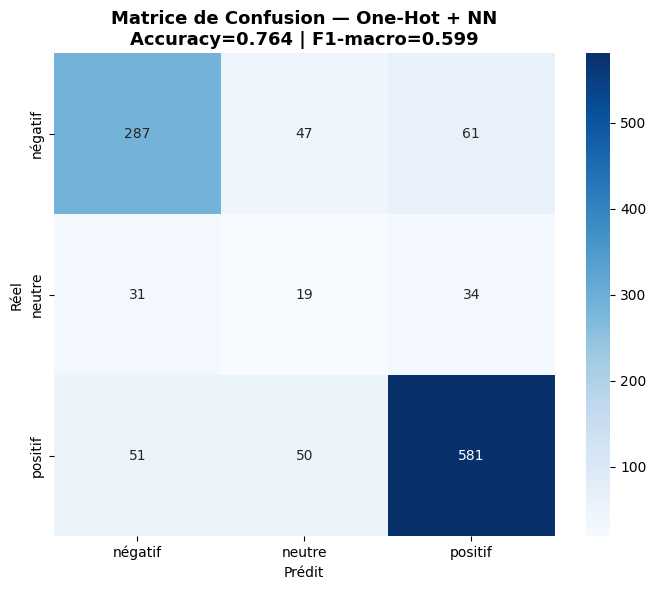

In [7]:
# ═══════════════════════════════════════════════════════
# ÉVALUATION SUR LE TEST SET
# ═══════════════════════════════════════════════════════
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_t)
    test_preds = test_outputs.argmax(dim=1).cpu().numpy()

test_acc = accuracy_score(y_test, test_preds)
test_f1  = f1_score(y_test, test_preds, average='macro')

print("="*60)
print("📊 RÉSULTATS — One-Hot + Réseau Neuronal")
print("="*60)
print(f"   Accuracy  : {test_acc:.4f}")
print(f"   F1-macro  : {test_f1:.4f}")
print(f"\n Classification Report :")
print(classification_report(y_test, test_preds, target_names=['négatif','neutre','positif']))

# Matrice de confusion
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['négatif','neutre','positif'],
            yticklabels=['négatif','neutre','positif'])
ax.set_xlabel('Prédit')
ax.set_ylabel('Réel')
ax.set_title(f'Matrice de Confusion — One-Hot + NN\nAccuracy={test_acc:.3f} | F1-macro={test_f1:.3f}',
            fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'confusion_onehot_nn.png'), dpi=150, bbox_inches='tight')
plt.show()